##### Feladat (Példatár 1.21)

Az ábrán látható összetett keresztmetszet terhelése $20 ~\mathrm{kN}$ nagyságú nyíró igénybevétel. Határozza meg a keresztmetszet mentén a nyírásból adódó csúsztatófeszültségek eloszlását megadó $\tau (y)$ függvényt és annak maximumát!

<img src="img/01.jpg" alt="Feladat" width=150px>

##### Csomagok importálása

In [1]:
import numpy as np # Numerikus számítások
import matplotlib.pyplot as plt # Ábrázolás
plt.rcParams['mathtext.fontset'] = 'cm' # Betűtípus az ábrákon
plt.rcParams['font.family'] = 'serif' # Betűtípus az ábrákon
plt.rcParams['font.serif'] = ['cmr10'] # Betűtípus az ábrákon
plt.rcParams['axes.formatter.use_mathtext'] = True # Betűtípus az ábrákon
plt.rcParams['axes.unicode_minus'] = False # Betűtípus az ábrákon
from IPython.display import display, Math, Latex # Szép kimenet Jupyter notebookban
import sympy as sp # Szimbólikus számítások
from sympy import latex # Szép kimenet Jupyter notebookban
sp.init_printing() # Szép kimenet Jupyter notebookban

##### Adatok

In [2]:
V_data = 20 # kN
a_data = 20 # mm
b_data = 100 # mm

# Átváltás N, mm, MPa rendszerbe
V_data = V_data * 10**3 # Nmm

In [3]:
V, y, a, b = sp.symbols('V, y, a, b')

In [4]:
data = [(V, V_data),
        (a, a_data),
        (b, b_data)]

##### Csúsztatófeszültség eloszlás meghatározása

$$\tau (y) = \frac{V}{I_z} \cdot \frac{S(y)}{a(y)}$$

ahol:
- $V$: nyíróerő,
- $I_z$: a nyírás tengelyére számolt másodrendű nyomaték,
- $S(y)$: az elhagyott keresztmetszet rész statikai nyomatéka a súlyponti tengelyre,
- $a(y)$: a keresztmetszet húsvastagsága.

##### Mivel a húsvastagság változik, ezért részekre kell bontani

##### Másodrendű nyomaték számítása

In [5]:
I_z = a*(3*b)**3/12 + 2 * a*b**3/12
I_z = I_z.subs(data)
display(Math(rf'I_z = {latex(round(I_z, 3))} ~\mathrm{{mm^4}}'))

<IPython.core.display.Math object>

##### I. rész: $y \in [\frac{b}{2}, \frac{3b}{2}]$

<img src="img/02.jpg" alt="Feladat" width=300px>

In [6]:
# Húsvastagság
a_I = a
display(Math(rf'a_I(y) = {latex(a_I.expand().subs(data))}'))

# Statikai nyomaték
A_I = a*(3/2*b - y)
k_I = (3/2*b + y) / 2
S_I = A_I * k_I

display(Math(rf'S_I(y) = {latex(S_I.expand().subs(data))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [7]:
# Csúsztatófeszültség
tau_I = V / I_z * S_I / a_I
display(Math(rf'\tau_I(y) = {latex(tau_I.subs(data).simplify().evalf(5))}'))

<IPython.core.display.Math object>

##### 2. rész: $y \in [0, \frac{b}{2}]$

<img src="img/03.jpg" alt="Feladat" width=300px>

In [8]:
# Húsvastagság
a_II = 3*a
display(Math(rf'a_{{II}}(y) = {latex(a_II.expand().subs(data))}'))

# Statikai nyomaték
A_II1 = a*b
k_II1 = b
A_II2 = a_II * (b/2 - y)
k_II2 = (b/2 + y) / 2

S_II = A_II1 * k_II1 + A_II2 * k_II2

display(Math(rf'S_{{II}}(y) = {latex(S_II.expand().subs(data))}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

In [9]:
# Csúsztatófeszültség
tau_II = V / I_z * S_II / a_II
display(Math(rf'\tau_{{II}}(y) = {latex(tau_II.subs(data).simplify().evalf(5))}'))

<IPython.core.display.Math object>

##### Csúsztatófeszültség eloszlása

In [10]:
# Nevezetes pontokban

y_A = 3/2*b
tau_A = tau_I.subs(y,y_A).subs(data)
display(Math(rf'\tau_{{A}} = {latex(round(tau_A, 4))} ~\mathrm{{MPa}}'))

y_B = b/2
tau_BI = tau_I.subs(y,y_B).subs(data)
display(Math(rf'\tau_{{B,I}} = {latex(round(tau_BI, 4))} ~\mathrm{{MPa}}'))

y_B = b/2
tau_BII = tau_II.subs(y,y_B).subs(data)
display(Math(rf'\tau_{{B,II}} = {latex(round(tau_BII, 4))} ~\mathrm{{MPa}}'))

y_C = 0
tau_C = tau_II.subs(y,y_C).subs(data)
display(Math(rf'\tau_{{C}} = {latex(round(tau_C, 4))} ~\mathrm{{MPa}}'))

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

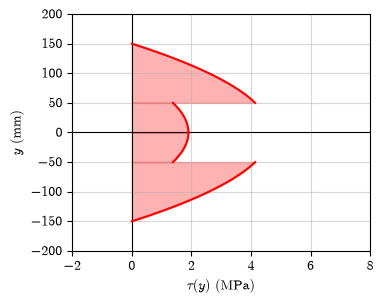

In [11]:
tau_I_sym = tau_I.subs(data)
tau_I_num = sp.lambdify(y, tau_I_sym)

tau_II_sym = tau_II.subs(data)
tau_II_num = sp.lambdify(y, tau_II_sym)

y_I_vals = np.linspace(float(y_A.subs(data)), float(y_B.subs(data)))
y_II_vals = np.linspace(float(y_B.subs(data)), float(y_C))

tau_I_vals = tau_I_num(y_I_vals)
tau_II_vals = tau_II_num(y_II_vals)

plt.figure(figsize=(10/2.54, 8/2.54))

plt.plot(tau_I_vals, y_I_vals, color='red', zorder=5)
plt.fill_betweenx(y_I_vals, tau_I_vals, 0, color='red', alpha=0.3)
plt.plot(tau_II_vals, y_II_vals, color='red', zorder=5)
plt.fill_betweenx(y_II_vals, tau_II_vals, 0, color='red', alpha=0.3)

plt.plot(tau_I_vals, -y_I_vals, color='red', zorder=5)
plt.fill_betweenx(-y_I_vals, tau_I_vals, 0, color='red', alpha=0.3)
plt.plot(tau_II_vals, -y_II_vals, color='red', zorder=5)
plt.fill_betweenx(-y_II_vals, tau_II_vals, 0, color='red', alpha=0.3)

plt.axhline(0, color='black', linewidth=0.8)
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel(r'$\tau (y) ~ \mathrm{(MPa)}$')
plt.ylabel(r'$y ~ \mathrm{(mm)}$')
plt.grid(True, alpha=0.5)
plt.xlim(-2, 8)
plt.ylim(-200, 200)
plt.tight_layout()
plt.savefig('csusztatofeszultseg_eloszlas.pdf')
plt.show()